In [1]:
%cd /Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code

%pwd


/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code


'/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code'

In [2]:


import numpy as np
from typing import Union, Optional, List, Any, Tuple, Callable, Dict
from itertools import product
import pandas
import matplotlib.pyplot as plt

from scipy.sparse.linalg import cg
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml


import landmark
import voltagemap
import problem
import solver
import visualization
import setofpoints
import kmeans
from Utilities import config



In [3]:

workspace_file="../../Voltage_Temp/Intermediates/workspace.pkl"
!ls -lh $workspace_file
import dill
dill.load_session(workspace_file)


-rw-r--r--@ 1 yoavfreund  staff    29M Jul  7 16:50 ../../Voltage_Temp/Intermediates/workspace.pkl


In [7]:



DEflat = Deuc.flatten()
DEflat = np.nan_to_num(DEflat, nan=0.0, neginf=0.0, posinf=0.0)
DVflat = Dvolt.flatten()
DVflat = np.nan_to_num(DVflat, nan=0.0, neginf=0.0, posinf=0.0)

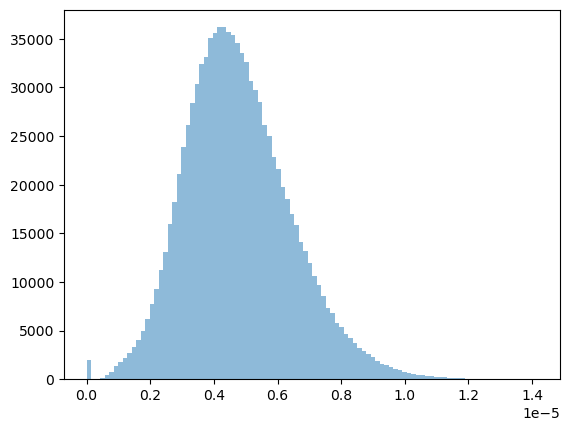

In [61]:
DEflat = DEflat/1e6
plt.hist(DEflat, bins=100, alpha=0.5, label='Euclidean');

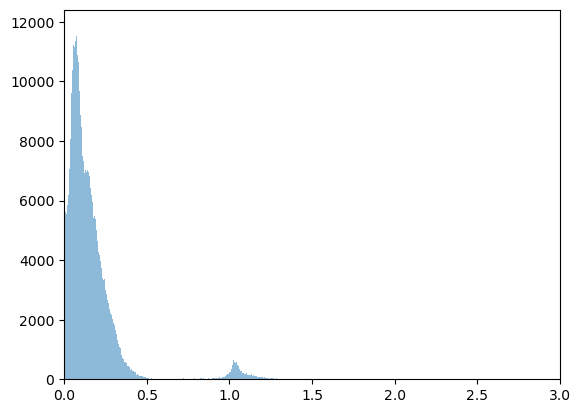

In [62]:
plt.hist(Dvolt.flatten(), bins=1000, alpha=0.5, label='Euclidean');
plt.xlim(0, 3.0);

In [10]:
for i in range(y.shape[0]):
    if y[i] is None:
        y[i] = '-1'
    y[i]=int(y[i])
    
    

In [11]:
y[:10]

array([-1, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=object)

In [12]:
diff_matrix =-np.ones((y.shape[0],y.shape[0]))
for i in range(y.shape[0]):
    for j in range(y.shape[0]):
        if y[i]<y[j]:
            diff_matrix[i,j]=y[i]# *10+y[j]
        else:
            diff_matrix[i,j]=y[j]# *10+y[i]



np.min(diff_matrix), np.max(diff_matrix), np.mean(diff_matrix)
C=diff_matrix.flatten()


Text(0.5, 1.0, 'Filtered Points in Euclidean vs Voltage Distance')

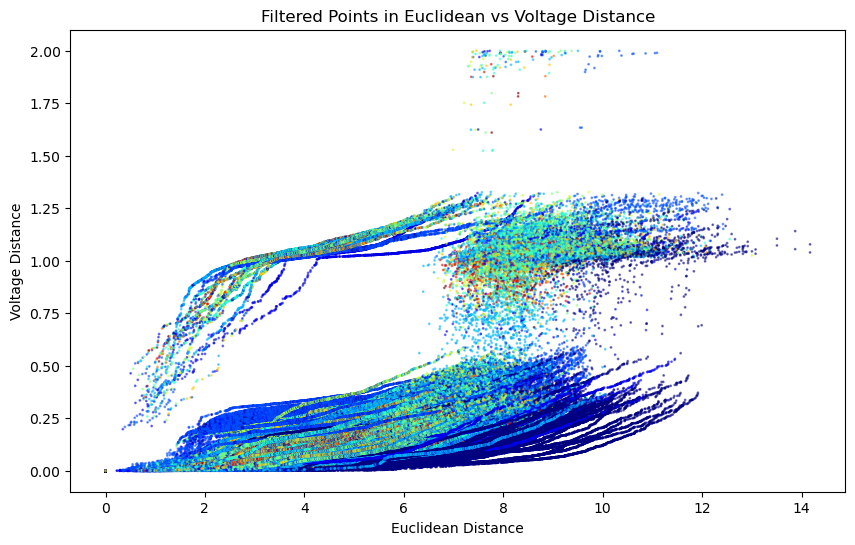

In [16]:
mask = (DEflat < 200) & (DVflat < 2.0)
# Get indices
indices = np.where(mask)[0]
plt.figure(figsize=(10, 6))
plt.scatter(DEflat[indices], DVflat[indices], s=1, alpha=0.5, c=C[indices], label='Filtered Points',cmap='jet');
plt.xlabel('Euclidean Distance')
plt.ylabel('Voltage Distance')
plt.title('Filtered Points in Euclidean vs Voltage Distance')

In [54]:
V=voltages_so_far.flatten()
plt.hist(max_voltage,bins=100);

NameError: name 'voltages_so_far' is not defined

In [57]:
import numpy as np
from collections import Counter

def knn_error(D, y, k=1):
    """
    Compute leave-one-out KNN classification error given a distance matrix.

    Parameters:
        D : (n_samples, n_samples) ndarray
            Pairwise distance matrix. D[i, j] = distance from i to j.
        y : (n_samples,) ndarray
            True class labels.
        k : int
            Number of neighbors.

    Returns:
        error_rate : float
            Fraction of incorrect predictions.
    """
    np.fill_diagonal(D, 0)  # Exclude self from neighbors
    n_samples = D.shape[0]
    errors = 0

    for i in range(n_samples):
        # Get distances to all other points
        distances = D[i].copy()
        distances[i] = np.inf  # exclude self

        # Get indices of k nearest neighbors
        neighbors = np.argpartition(distances, k)[:k]

        # Majority vote
        neighbor_labels = y[neighbors]
        most_common_label, _ = Counter(neighbor_labels).most_common(1)[0]

        # Compare to true label
        if most_common_label != y[i]:
            errors += 1

    error_rate = errors / n_samples
    return error_rate


In [58]:
# Compute the k-NN error for Dvolt

knn_error_dvolt = knn_error(Dvolt, y, k=10)
print(f"k-NN error for Dvolt: {knn_error_dvolt:.4f}")

k-NN error for Dvolt: 0.9620


In [59]:
knn_error_deuc = knn_error(Deuc, y, k=10)
print(f"k-NN error for Deuc: {knn_error_deuc:.4f}")

k-NN error for Deuc: 0.9620
